<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/14%EC%9E%A5_(1)LSTM%EC%A3%BC%EA%B0%80%EB%B6%84%EC%84%9D_2026_04_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝분석_(1)LSTM주가분석

In [1]:
# 주가 데이터를 다운로드 받기 위해서 야후 파이낸스 라이브러리 설치
!pip install yfinance

# 1. 데이터 수집

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

### - 기업 주가 데이터를 다운로드하여 데이터프레임으로 저장

In [3]:
name = 'GOOG'  #종목명 -구글

start_day = '2021-01-01'
end_day = '2024-08-01'

In [4]:
stock = yf.download(name, start=start_day, end=end_day)

/tmp/ipykernel_5536/3346645531.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(name, start=start_day, end=end_day)
[*********************100%***********************]  1 of 1 completed


In [5]:
print(stock.shape)  #작업 확인용 출력
stock.head() #작업 확인용 출력

(899, 5)


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2021-01-04,85.708351,87.315654,84.697152,87.161418,38038000
2021-01-05,86.337181,86.671934,85.201258,85.547665,22906000
2021-01-06,86.057976,86.688299,84.258245,84.438270,52042000
2021-01-07,88.634827,88.691854,86.145263,86.294535,45300000
2021-01-08,89.624680,89.755109,87.954644,88.671015,41012000


# 2. 데이터 준비 및 탐색

### - 분석할 컬럼(날짜, 종가) 추출

In [6]:
stock2 = pd.DataFrame(stock['Close'])

stock2.head() #작업 확인용 출력

Ticker,GOOG
Date,
2021-01-04,85.708351
2021-01-05,86.337181
2021-01-06,86.057976
2021-01-07,88.634827
2021-01-08,89.624680


#### - 파일 저장

In [8]:
import os

# Create the directory if it doesn't exist
os.makedirs('./content/', exist_ok=True)

# 다운로드한 주가 데이터를 파일 저장
stock2.to_csv('./content/'+name+'.csv')

### - 데이터 정규화

In [9]:
stock2.reset_index()
stock_values = stock2.values

print(stock_values[0]) #작업 확인용 출력

[85.70835114]


### - 0~1 범위로 스케일링

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler(feature_range=(0,1))
stock_values_scaled=scaler.fit_transform(stock_values)

stock_values_scaled[0] #작업 확인용 출력

array([0.02671205])

# 3. 분석 모델 구축

## 3-1. 주가 분석 모델의 학습용 데이터 준비

In [12]:
n_train = int(len(stock_values)*0.8)  #학습용 데이터 갯수
n_test = len(stock_values) - n_train  #평가용 데이터 갯수

print(n_train, n_test) #작업 확인용 출력

719 180


In [13]:
X_train,Y_train=[],[]

#20일 구간의 주가를 x 값으로하고, 그 다음날 값을 y 값으로 정리하기
for i in range(20, n_train):
  X_train.append(stock_values_scaled[i-20:i,0])
  Y_train.append(stock_values_scaled[i,0])

X_train[0] #작업 확인용 출력

array([0.02671205, 0.0325078 , 0.02993444, 0.05368455, 0.06280775,
       0.04430054, 0.03508115, 0.0386692 , 0.03216943, 0.03034587,
       0.05533463, 0.09923282, 0.1012212 , 0.10570045, 0.10494622,
       0.11310072, 0.07358581, 0.0883587 , 0.0758485 , 0.10583772])

### - LSTM 모델의 입력층의 구조로 변형_reshape()

In [14]:
X_train1, Y_train1 = np.array(X_train), np.array(Y_train)
X_train2 = np.reshape(X_train1, (X_train1.shape[0],X_train1.shape[1],1))

print(X_train2.shape) #작업 확인용 출력
X_train2[0] #작업 확인용 출력

(699, 20, 1)


array([[0.02671205],
       [0.0325078 ],
       [0.02993444],
       [0.05368455],
       [0.06280775],
       [0.04430054],
       [0.03508115],
       [0.0386692 ],
       [0.03216943],
       [0.03034587],
       [0.05533463],
       [0.09923282],
       [0.1012212 ],
       [0.10570045],
       [0.10494622],
       [0.11310072],
       [0.07358581],
       [0.0883587 ],
       [0.0758485 ],
       [0.10583772]])

## 3-2. LSTM 모델 구축

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

### - LSTM 모델 구성

In [16]:
lstm_stock = Sequential()

lstm_stock.add(LSTM(units=20, return_sequences=True, input_shape=(X_train2.shape[1],1)))
lstm_stock.add(LSTM(units=20, return_sequences=False))
lstm_stock.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### - LSTM 모델 학습

In [17]:
#학습 파라미터  설정
lstm_stock.compile(loss='mean_squared_error', optimizer='adam')

#학습 수행
lstm_stock.fit(X_train2, Y_train1, epochs=10, batch_size=1, verbose=2)

Epoch 1/10
699/699 - 13s - 18ms/step - loss: 0.0035
Epoch 2/10
699/699 - 8s - 12ms/step - loss: 0.0020
Epoch 3/10
699/699 - 9s - 13ms/step - loss: 0.0014
Epoch 4/10
699/699 - 8s - 12ms/step - loss: 0.0012
Epoch 5/10
699/699 - 7s - 11ms/step - loss: 0.0010
Epoch 6/10
699/699 - 8s - 11ms/step - loss: 8.2542e-04
Epoch 7/10
699/699 - 11s - 15ms/step - loss: 7.0583e-04
Epoch 8/10
699/699 - 7s - 10ms/step - loss: 6.9875e-04
Epoch 9/10
699/699 - 10s - 15ms/step - loss: 6.5066e-04
Epoch 10/10
699/699 - 8s - 12ms/step - loss: 6.2493e-04


## 3-3. 평가 데이터로 주가 예측

### - 평가용 데이터 만들기

In [18]:
stock_test = stock_values_scaled[n_train-20:]
X_test = []

for i in range(20, len(stock_test)):
  X_test.append(stock_test[i-20:i,0])


X_test[0] #작업 확인용 출력

array([0.50361434, 0.52107515, 0.52564581, 0.51001356, 0.50727088,
       0.48679372, 0.49739781, 0.51769257, 0.39473713, 0.36520963,
       0.36484397, 0.38632689, 0.38221308, 0.40296469, 0.41219772,
       0.42856142, 0.43843435, 0.4471189 , 0.4549806 , 0.44062827])

### - LSTM 모델의 입력층의 구조로 변형_reshape()

In [19]:
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

print(X_test.shape)  #작업 확인용 출력
print(X_test[0])

(180, 20, 1)
[[0.50361434]
 [0.52107515]
 [0.52564581]
 [0.51001356]
 [0.50727088]
 [0.48679372]
 [0.49739781]
 [0.51769257]
 [0.39473713]
 [0.36520963]
 [0.36484397]
 [0.38632689]
 [0.38221308]
 [0.40296469]
 [0.41219772]
 [0.42856142]
 [0.43843435]
 [0.4471189 ]
 [0.4549806 ]
 [0.44062827]]


### - 모델 예측 수행

In [20]:
predicted_value = lstm_stock.predict(X_test)

predicted_value[0] #작업 확인용 출력

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


array([0.43896613], dtype=float32)

# 4. 결과 분석 및 시각화

##### - 예측값을 스케일링 이전 값(원래 주가)으로 되돌림.

In [21]:
predicted_value = scaler.inverse_transform(predicted_value)

predicted_value[0] #작업 확인용 출력

array([130.43729], dtype=float32)

### - 그래프에 사용할 데이터 리스트 정리하기

In [22]:
stock_train_vis = stock[:n_train]
stock_test_vis = stock[n_train:]
stock_test_vis['Predictions'] = predicted_value

/tmp/ipykernel_5536/2531245371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_test_vis['Predictions'] = predicted_value


In [23]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'GOOG (2021-01-01 ~ 2024-08-01 )')

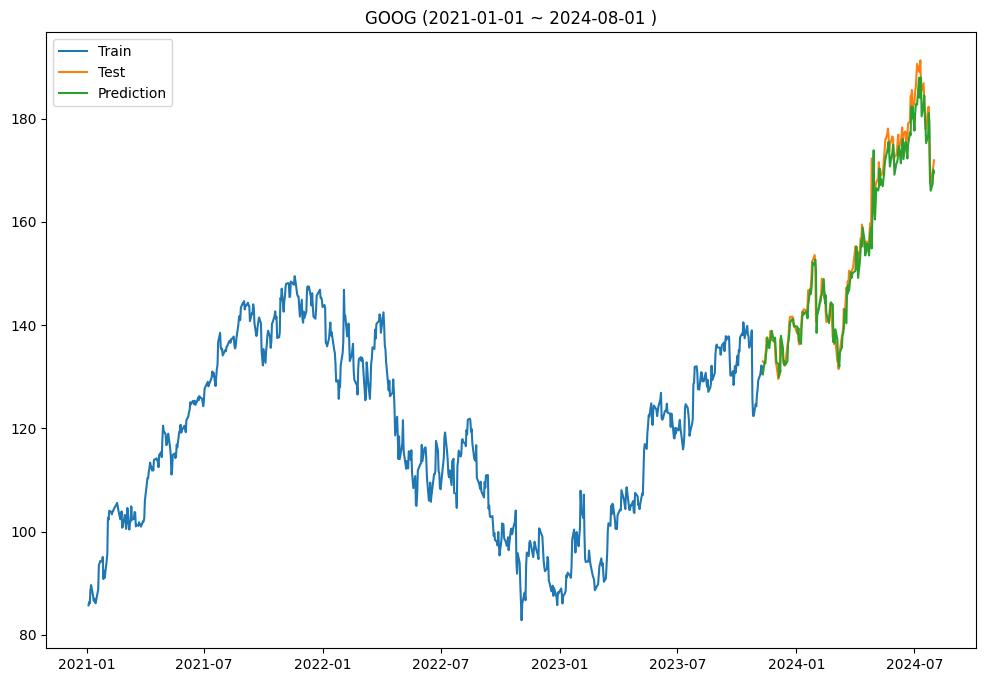

In [24]:
plt.figure(figsize = (12,8))
plt.plot(stock_train_vis['Close'], label = 'Train')
plt.plot(stock_test_vis['Close'], label = 'Test')
plt.plot(stock_test_vis['Predictions'], label = 'Prediction')
plt.legend()
plt.title(name + ' (' + start_day + ' ~ ' + end_day + ' )')